TRAINING A PERCEPTRON

In [1]:
import numpy as np

class Perceptron:

    def __init__(self, learning_rate=0.01, num_iterations=1000):
        self.lr = learning_rate
        self.n_iters = num_iterations
        self.activation_function = self.relu_function
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation_function(linear_output)

                update = self.lr * (y[idx] - y_predicted)
                self.weights += update * x_i
                self.bias += update

    def relu_function(self, x):
        return np.maximum(0, x)

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        y_predicted = self.activation_function(linear_output)
        return y_predicted


X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

perceptron = Perceptron(learning_rate=0.1, num_iterations=10)
perceptron.fit(X, y)

print("Predictions:", perceptron.predict(X))

Predictions: [0.         0.32466043 0.34414617 0.67441927]


ACTIVATION FUNCTION



In [3]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
x = tf.linspace(-10, 10, 100)
x

<tf.Tensor: shape=(100,), dtype=float64, numpy=
array([-10.        ,  -9.7979798 ,  -9.5959596 ,  -9.39393939,
        -9.19191919,  -8.98989899,  -8.78787879,  -8.58585859,
        -8.38383838,  -8.18181818,  -7.97979798,  -7.77777778,
        -7.57575758,  -7.37373737,  -7.17171717,  -6.96969697,
        -6.76767677,  -6.56565657,  -6.36363636,  -6.16161616,
        -5.95959596,  -5.75757576,  -5.55555556,  -5.35353535,
        -5.15151515,  -4.94949495,  -4.74747475,  -4.54545455,
        -4.34343434,  -4.14141414,  -3.93939394,  -3.73737374,
        -3.53535354,  -3.33333333,  -3.13131313,  -2.92929293,
        -2.72727273,  -2.52525253,  -2.32323232,  -2.12121212,
        -1.91919192,  -1.71717172,  -1.51515152,  -1.31313131,
        -1.11111111,  -0.90909091,  -0.70707071,  -0.50505051,
        -0.3030303 ,  -0.1010101 ,   0.1010101 ,   0.3030303 ,
         0.50505051,   0.70707071,   0.90909091,   1.11111111,
         1.31313131,   1.51515152,   1.71717172,   1.91919192,
       

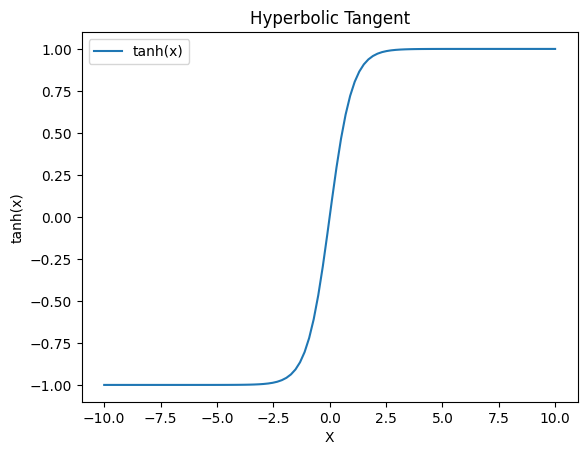

In [5]:
y = tf.keras.activations.tanh(x)

plt.plot(x, y, label="tanh(x)")
plt.title("Hyperbolic Tangent")
plt.xlabel("X")
plt.ylabel("tanh(x)")
plt.legend()
plt.show()

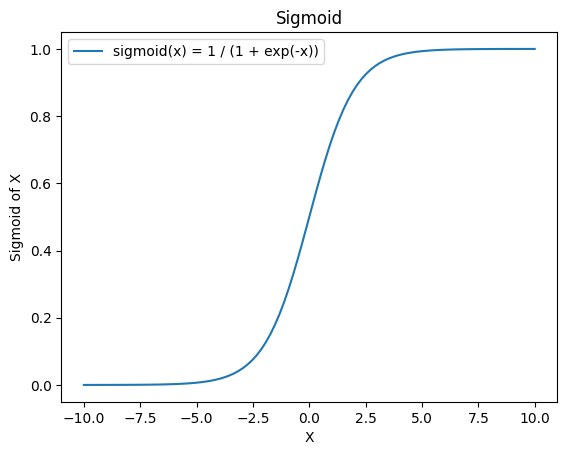

In [6]:
y = tf.keras.activations.sigmoid(x)

plt.plot(x, y, label="sigmoid(x) = 1 / (1 + exp(-x))")
plt.title("Sigmoid")
plt.xlabel("X")
plt.ylabel("Sigmoid of X")
plt.legend()
plt.show()

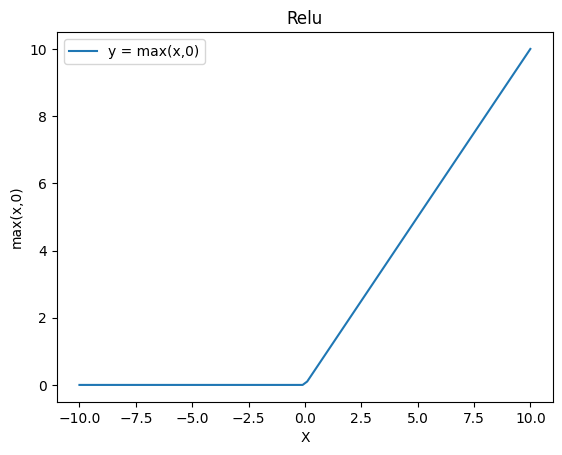

In [7]:
y = tf.keras.activations.relu(x)

plt.plot(x, y, label="y = max(x,0)")
plt.title("Relu")
plt.xlabel("X")
plt.ylabel("max(x,0)")
plt.legend()
plt.show()

/tmp/ipython-input-170/3976928010.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


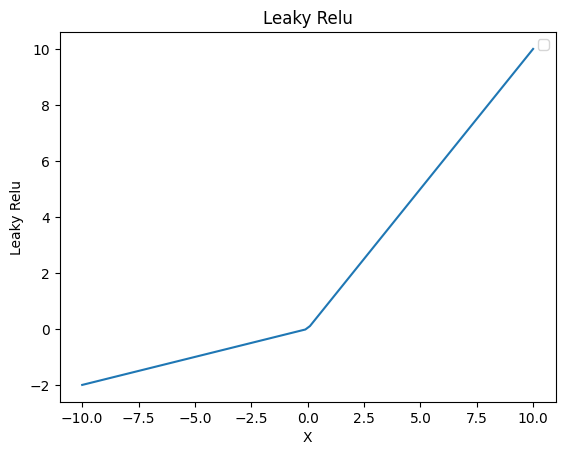

In [8]:
y = tf.nn.leaky_relu(x)

plt.plot(x, y)
plt.title("Leaky Relu")
plt.xlabel("X")
plt.ylabel("Leaky Relu")
plt.legend()
plt.show()

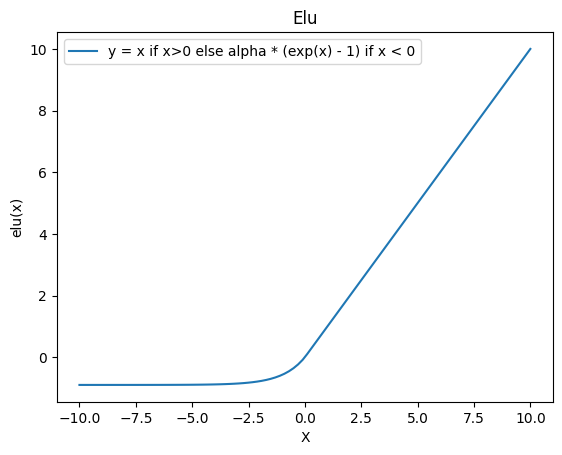

In [9]:
y = tf.keras.activations.elu(x, alpha=0.9)

plt.plot(x, y, label="y = x if x>0 else alpha * (exp(x) - 1) if x < 0")
plt.title("Elu")
plt.xlabel("X")
plt.ylabel("elu(x)")
plt.legend()
plt.show()

In [10]:
x = tf.constant([150, 50, 10], dtype=tf.float32)
x = tf.expand_dims(x, axis=0)
print(x.shape)

y = tf.keras.activations.softmax(x)
print(y)

(1, 3)
tf.Tensor([[1. 0. 0.]], shape=(1, 3), dtype=float32)
